# VLM post-training — SFT · GRPO · Distillation · Self-Distillation

**Four ways to teach a vision-language model, on one concrete task: turning a receipt image into structured JSON.**

This is the companion to the nanoVLM architecture walkthrough. Where that notebook asked *"how is a VLM
built?"*, this one asks *"once you have one, how do you teach it a task?"* — and walks the **four
post-training methods** implemented in this repo, dissecting the *actual* code in `src/vlm_workshop/`
and `train/` on real SROIE + CORD receipts.

| Method | One-line idea | Signal it learns from | Repo code |
|---|---|---|---|
| **SFT** | imitate the gold answer | gold JSON tokens (teacher-forced) | `train/sft.py` |
| **GRPO** (RL) | sample answers, reward the good ones | a scalar **reward** (local, no judge) | `train/grpo.py`, `reward.py` |
| **Distillation** (GKD) | copy a bigger teacher into a smaller student | the **teacher's token distribution** (JSD) | `train/distill.py`, `distill.py` |
| **Self-distillation** (SDFT) | let the model teach *itself* from a demo | its **own** adapter-disabled distribution | `train/sdft.py`, `sdft.py` |

The model is **Qwen3.5-4B** (and a **0.8B** student for distillation), fine-tuned with **bf16 LoRA**.
The reward and all metrics are **local and deterministic** — no LLM judge.

> **What this notebook does:** explain each method, run *cheap* live demos of its core mechanism
> (the reward, the loss mask, the teacher/student prompts), and read back the **real experiment
> results**. It does **not** launch full training runs — those are yours to run via the scripts
> (each section ends with the exact command). One optional cell at the end loads the trained model
> for a live extraction.

---
## Part 0 — Setup

Run from the repo root with the code importable as `vlm_workshop` (the package lives under `src/`).

In [1]:
import os, sys, json, glob, textwrap, inspect
# repo root + make `import vlm_workshop` work (mirrors the train/*.py scripts)
if not os.path.isdir("src/vlm_workshop"):
    os.chdir(os.path.dirname(os.path.abspath("workshop_walkthrough.ipynb")))
sys.path.insert(0, os.path.join(os.getcwd(), "src"))
os.environ.setdefault("HF_HOME", "/workspace/.hf_home")
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
print("repo root:", os.getcwd())

import torch
print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

def show(name, t):
    if isinstance(t, torch.Tensor):
        print(f"{name:<30} shape={tuple(t.shape)}  dtype={t.dtype}")
    else:
        print(f"{name:<30} {t}")

repo root: /workspace/vlm_workshop


torch: 2.11.0+cu128 | CUDA: True | NVIDIA RTX PRO 6000 Blackwell Workstation Edition


The repo is small and layered — every method reuses the same data, prompts, and metric code:

| File | Role |
|---|---|
| `common.py` | model/processor loading, LoRA targets, token-id derivation |
| `prompts.py` | per-dataset instruction + JSON schema |
| `data.py` | SROIE+CORD → one unified schema; the SFT collator; the GRPO dataset |
| `metrics.py` | JSON extraction + **leaf-multiset** scoring (shared by reward *and* eval) |
| `reward.py` | the local GRPO reward built on `metrics` |
| `distill.py` / `sdft.py` | the VLM-aware GKD / SDFT trainers |
| `train/*.py` | the four training entry points |

We'll meet each in turn.

---
## Part 1 — The task and the data

Two receipt datasets, unified into one multi-task extraction problem:

* **SROIE** — *flat* key-information extraction: 4 header fields (`company`, `date`, `address`, `total`).
* **CORD** — *nested* itemized parsing: a `menu` list of line items (`nm`/`cnt`/`price`) plus subtotal/total.

`data.py` normalizes **both** to one schema: `{image, dataset, target(JSON string)}`. Let's load one of each.

In [2]:
from vlm_workshop.data import build_unified, DEFAULT_MAX_PIXELS

# one SROIE + one CORD training row (datasets are cached locally)
unified = build_unified({"sroie": "train", "cord": "train"}, limit_per_dataset=1,
                        max_pixels=DEFAULT_MAX_PIXELS)
print("unified columns:", unified.column_names, "| rows:", len(unified),
      "| datasets:", list(unified["dataset"]))

by = {r["dataset"]: r for r in unified}
for name in ("sroie", "cord"):
    print(f"\n=== {name} target JSON ===")
    print(textwrap.indent(json.dumps(json.loads(by[name]["target"]), indent=2)[:400], "  "))

unified columns: ['image', 'dataset', 'target'] | rows: 2 | datasets: ['cord', 'sroie']

=== sroie target JSON ===
  {
    "company": "BOOK TA .K (TAMAN DAYA) SDN BHD",
    "date": "25/12/2018",
    "address": "NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.",
    "total": "9.00"
  }

=== cord target JSON ===
  {
    "menu": [
      {
        "nm": "Nasi Campur Bali",
        "cnt": "1 x",
        "price": "75,000"
      },
      {
        "nm": "Bbk Bengil Nasi",
        "cnt": "1 x",
        "price": "125,000"
      },
      {
        "nm": "MilkShake Starwb",
        "cnt": "1 x",
        "price": "37,000"
      },
      {
        "nm": "Ice Lemon Tea",
        "cnt": "1 x",
        "price": "24,000"
      },
      {
        "nm": "Nasi Ayam Dewa


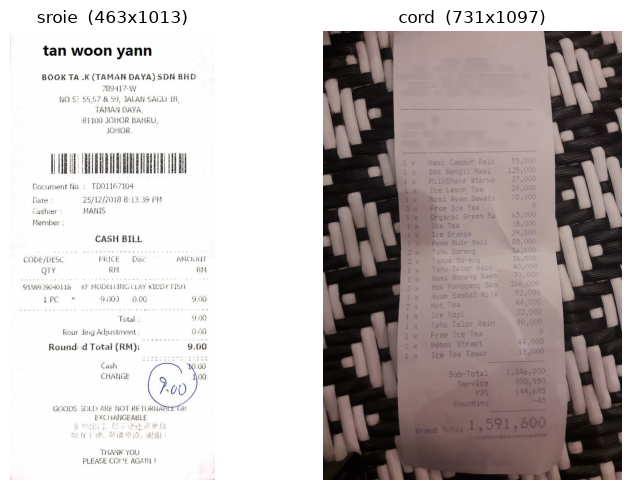

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(8, 5))
for a, name in zip(ax, ("sroie", "cord")):
    a.imshow(by[name]["image"]); a.axis("off")
    a.set_title(f"{name}  ({by[name]['image'].size[0]}x{by[name]['image'].size[1]})")
plt.tight_layout(); plt.show()

### The prompt

Each row becomes one user turn: **instruction + image + the JSON schema** to fill (`prompts.py`). Keeping
the answer as a fenced ```json block makes parsing trivial at reward/eval time.

In [4]:
from vlm_workshop.prompts import PROMPTS, build_user_content
content = build_user_content("sroie", by["sroie"]["image"], DEFAULT_MAX_PIXELS)
for part in content:
    kind = part["type"]
    txt = part.get("text")
    print(f"[{kind}]", (textwrap.shorten(txt, 90) if txt else "<the receipt image>"))

[text] You are a receipt information extraction system. Extract the key header fields from [...]
[image] <the receipt image>
[text] Return ONLY valid JSON matching this schema (no prose, no markdown outside the json [...]


### The metric engine — one code path for flat *and* nested JSON

Both the **reward** (Part 3) and the **eval** report use `metrics.py`. The trick that makes SROIE's flat
fields and CORD's nested `gt_parse` comparable with one function: flatten any JSON into a **multiset of
`(leaf-key, normalized-value)` pairs**, dropping list indices so repeated line-items collapse onto the
same key (e.g. `menu.nm`). From that multiset:

* **field_f1** — F1 over the leaf **keys** (did it find the right fields)
* **pair_f1** — F1 over `(key, value)` pairs (**headline** — did it extract them right)
* **value_acc** — of shared keys, fraction with the correct value

Values are normalized (lowercase, strip currency/commas, canonicalize numbers) so `RM 1,000.00` == `1000`.

In [5]:
from vlm_workshop.metrics import flatten_leaves, score, norm_value

gold = {"company": "ACME SDN BHD", "date": "25/12/2018", "total": "1,000.00"}
pred = {"company": "acme sdn bhd", "date": "25/12/2018", "total": "1,000"}  # messy but equivalent
print("gold leaves:", list(flatten_leaves(gold)))
print("pred leaves:", list(flatten_leaves(pred)), "  <- '1,000.00' and '1,000' both normalize to '1000'")
print("\nscore(pred, gold):", {k: round(v, 3) for k, v in score(pred, gold).items()})

# what normalization does: lowercase, strip commas / currency ($, Rp), canonicalize numbers
print("\nnorm_value:  '1,000.00' ->", norm_value("1,000.00"), " | 'Rp 1000' ->", norm_value("Rp 1000"),
      " | '  ACME  ' ->", repr(norm_value("  ACME  ")))

# nested CORD-style target flattens the same way (list indices dropped -> repeated keys)
nested = {"menu": [{"nm": "Coffee", "price": "3.00"}, {"nm": "Tea", "price": "2.50"}]}
print("\nnested leaves:", list(flatten_leaves(nested)))

gold leaves: [('company', 'acme sdn bhd'), ('date', '25/12/2018'), ('total', '1000')]
pred leaves: [('company', 'acme sdn bhd'), ('date', '25/12/2018'), ('total', '1000')]   <- '1,000.00' and '1,000' both normalize to '1000'

score(pred, gold): {'field_f1': 1.0, 'pair_f1': 1.0, 'value_acc': 1.0, 'precision': 1.0, 'recall': 1.0}

norm_value:  '1,000.00' -> 1000  | 'Rp 1000' -> 1000  | '  ACME  ' -> 'acme'

nested leaves: [('menu.nm', 'coffee'), ('menu.price', '3'), ('menu.nm', 'tea'), ('menu.price', '2.5')]


---
## Part 2 — Method 1: SFT (Supervised Fine-Tuning)

**Idea:** show the model `(image, prompt) → gold JSON` and train it to reproduce the gold tokens. Plain
next-token cross-entropy, but with two VLM-specific twists that live in `data.sft_collate_fn`:

1. **LoRA, not full fine-tuning.** The 4B weights are frozen; we train small low-rank adapters
   (`r=32`) on the attention + MLP projections (`common.LORA_TARGETS`). ~0.5–1.5% of params train.
2. **Completion-only loss + vision masking.** We only supervise the *assistant's answer*. The prompt,
   the schema, and every **vision token** are set to `-100` (ignored by the loss) — you don't want to
   train the model to "predict the image."

Let's run the real collator on one sample and look at the label mask.

In [6]:
from vlm_workshop.common import load_processor, vision_token_ids, assistant_marker_ids, LORA_TARGETS
from vlm_workshop.data import sft_collate_fn

processor = load_processor()                     # Qwen3.5 processor (tokenizer + image processor)
batch = sft_collate_fn([by["sroie"]], processor, DEFAULT_MAX_PIXELS,
                       vision_token_ids(processor), assistant_marker_ids(processor))

show("input_ids", batch["input_ids"])
show("labels", batch["labels"])
n_sup = int((batch["labels"] != -100).sum()); n_tot = batch["labels"].numel()
print(f"\nsupervised (label != -100): {n_sup} / {n_tot} tokens "
      f"({100*n_sup/n_tot:.0f}%) — only the assistant JSON is trained on")
sup_ids = batch["input_ids"][0][batch["labels"][0] != -100]
print("\nsupervised tokens decode to the gold answer:\n",
      textwrap.shorten(processor.tokenizer.decode(sup_ids), 200))

input_ids                      shape=(1, 672)  dtype=torch.int64
labels                         shape=(1, 672)  dtype=torch.int64

supervised (label != -100): 114 / 672 tokens (17%) — only the assistant JSON is trained on

supervised tokens decode to the gold answer:
 <think> </think> ```json { "company": "BOOK TA .K (TAMAN DAYA) SDN BHD", "date": "25/12/2018", "address": "NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.", "total": [...]


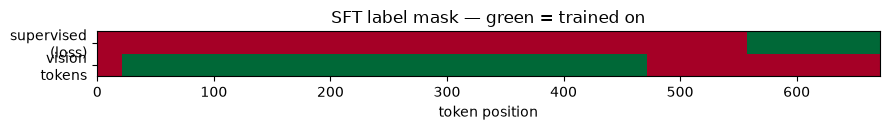

The green block on the right is the assistant JSON. Everything before it (prompt + image) is masked.


In [7]:
# Visualise the mask over the sequence: which positions carry a loss?
import numpy as np
mask = (batch["labels"][0] != -100).int().numpy()
vis_ids = vision_token_ids(processor)
is_vision = np.isin(batch["input_ids"][0].numpy(), vis_ids).astype(int)
fig, ax = plt.subplots(figsize=(9, 1.4))
ax.imshow(np.stack([mask, is_vision]), aspect="auto", cmap="RdYlGn",
          interpolation="nearest")
ax.set_yticks([0, 1]); ax.set_yticklabels(["supervised\n(loss)", "vision\ntokens"])
ax.set_xlabel("token position"); ax.set_title("SFT label mask — green = trained on")
plt.tight_layout(); plt.show()
print("The green block on the right is the assistant JSON. Everything before it (prompt + image) is masked.")

### The training script (`train/sft.py`)

The collator above is handed to TRL's `SFTTrainer`. The key config:

```python
peft_config = LoraConfig(r=32, lora_alpha=32, target_modules=LORA_TARGETS, task_type="CAUSAL_LM")
cfg = SFTConfig(num_train_epochs=3, per_device_train_batch_size=2, gradient_accumulation_steps=8,
                learning_rate=2e-4, bf16=True, gradient_checkpointing=True,
                use_liger_kernel=True)     # liger = fused CE, avoids materializing 248k-vocab logits
```

In [8]:
print("LoRA target modules:", LORA_TARGETS)
# The Qwen3.5 vocab is large — that's why the liger fused cross-entropy matters for memory.
print("vocab size:", len(processor.tokenizer), "tokens")
print("\n>>> run it yourself:  python train/sft.py --datasets sroie,cord --report-to none")

LoRA target modules: ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
vocab size: 248077 tokens

>>> run it yourself:  python train/sft.py --datasets sroie,cord --report-to none


### Result — SFT does most of the work

Macro **pair_f1** on 100 SROIE + 100 CORD (from `outputs/eval/`):

| model | base | **SFT** |
|---|---|---|
| Qwen3.5-4B (instruct) | 0.795 | **0.900** |
| Gemma-4-E2B (raw base) | 0.000 | **0.863** |

The Gemma base can't emit valid JSON zero-shot at all (0.0) — SFT is a genuine 0 → 0.86 jump. We'll load
these numbers live and chart every method together in Part 6.

---
## Part 3 — Method 2: GRPO (reinforcement learning)

SFT imitates *one* gold answer. **GRPO** (Group Relative Policy Optimization) instead: for each prompt,
**sample several completions**, **score each with a reward**, and push the policy toward the
*above-average* ones. There are no gold tokens in the loss — only the scalar reward.

### The reward is local and deterministic (no LLM judge)

`reward.py` scores a completion against its target with the same leaf-multiset metric from Part 1:

$$\text{reward} = 0.30\cdot\text{parsable} + 0.50\cdot\text{field\_f1} + 0.20\cdot\text{value\_acc}$$

Run it on three completions — perfect, partial, and garbage:

In [9]:
from vlm_workshop.reward import receipt_reward, score_completion, WEIGHTS

gt = json.dumps({"company": "ACME SDN BHD", "date": "25/12/2018",
                 "address": "NO.53, JALAN SAGU", "total": "9.00"})
good    = "```json\n" + gt + "\n```"
partial = '```json\n{"company":"acme sdn bhd","total":"9.0"}\n```'   # 2/4 fields, values ok
bad     = "I think this is a receipt from a store."                  # not JSON

print("reward weights:", WEIGHTS, "\n")
for name, c in [("good", good), ("partial", partial), ("bad", bad)]:
    comp = score_completion(c, gt)
    print(f"{name:<8} reward={comp['total']:.3f}  "
          f"(parsable={comp['parsable']:.0f}  field_f1={comp['field_f1']:.2f}  value_acc={comp['value_acc']:.2f})")
print("\nas TRL calls it:", [round(x,3) for x in
      receipt_reward(completions=[good, partial, bad], dataset="sroie", target=gt)])

reward weights: {'parsable': 0.3, 'field_f1': 0.5, 'value_acc': 0.2} 

good     reward=1.000  (parsable=1  field_f1=1.00  value_acc=1.00)
partial  reward=0.833  (parsable=1  field_f1=0.67  value_acc=1.00)
bad      reward=0.000  (parsable=0  field_f1=0.00  value_acc=0.00)

as TRL calls it: [1.0, 0.833, 0.0]


### How GRPO turns those rewards into a gradient

```
prompt ─► sample G=8 completions ─► reward each ─► advantage_i = (r_i − mean) / std
                                                        │
                          push ↑ probability of tokens in above-average completions
                          push ↓ probability of tokens in below-average completions
```

Key config in `train/grpo.py` (`GRPOConfig`): `num_generations=8`, `max_completion_length=768`,
**`beta=0`** (no KL term → no frozen reference model needed), `lr=1e-5`, and the policy is the **SFT
adapter, loaded trainable** — GRPO *continues* SFT. Rollouts use TRL's transformers backend
(`use_vllm=False`): vLLM 0.24 (the only build supporting `Qwen3_5`) is CUDA-13, unavailable on this
Blackwell's 12.8 driver; 4B + short receipts keep sampling cheap.

> **Real-world footnote.** `train/grpo.py` also monkey-patches TRL's Liger loss to recompute
> `mm_token_type_ids` from `input_ids` — Qwen3.5's multimodal RoPE needs it, and TRL's text-only path
> drops it. This is what "RL on a brand-new VLM" actually looks like in practice.

### Result — GRPO was *flat* here, and the reason is the interesting part

| Qwen3.5-4B | SFT | **GRPO** |
|---|---|---|
| macro pair_f1 | 0.900 | **0.893** (−0.007) |

GRPO barely moved the needle. **Why:** after SFT, the 8 sampled completions per prompt almost all score
high (mean reward ≈ 0.98), so the within-group advantage `(r − mean)/std ≈ 0` → almost no gradient. **SFT
saturated the reward.** RL needs *headroom* and *reward variance* to bite — an under-trained SFT, or a
stricter all-or-nothing reward, would give GRPO something to fix. (We'll see distillation, where the small
student *does* have headroom, produce a real gain next.)

```bash
# your turn — continue the SFT adapter with GRPO:
python train/grpo.py --adapter outputs/sft --num-generations 8 --beta 0 --report-to none
```

---
## Part 4 — Method 3: On-policy distillation (GKD)

**Idea:** we have a strong 4B extractor (the SFT model, pair_f1 0.90). Can we get most of that quality in
a **5× smaller 0.8B** model? **GKD** (Generalized Knowledge Distillation = *on-policy* distillation):

```
student (0.8B) samples a completion ─► BOTH teacher (4B) and student score those same tokens
                                          │
              loss = generalized JS divergence between teacher & student next-token distributions
```

The student learns from the teacher's **full token distribution** — a much richer signal than a single
gold label (it sees *how confident* the teacher is over *every* alternative token).

### Why the same model family matters
Both are Qwen3.5: **identical vocab (248,077)** and **identical image tokenization** (a receipt → the
*same* number of `<|image_pad|>` tokens on both). So one `input_ids` sequence can be scored by teacher and
student, and a same-vocab JSD is well-defined.

In [10]:
from vlm_workshop.distill import VLMGKDCollator
from vlm_workshop.data import build_grpo_dataset

grpo_rows = build_grpo_dataset({"sroie": "train"}, limit_per_dataset=1)
gkd_collate = VLMGKDCollator(processor, DEFAULT_MAX_PIXELS,
                             vision_token_ids(processor), assistant_marker_ids(processor))
gkd_batch = gkd_collate([grpo_rows[0]])
print("GKD batch keys:", list(gkd_batch.keys()))
show("prompts (for on-policy generation)", gkd_batch["prompts"])
show("input_ids (prompt+gold, off-policy)", gkd_batch["input_ids"])
show("pixel_values (shared image)", gkd_batch["pixel_values"])
img_pad = processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")
n_img = int((gkd_batch["input_ids"] == img_pad).sum())
print(f"\n<|image_pad|> tokens in this sample: {n_img}  (same count on 4B and 0.8B — that's the point)")

/workspace/vlm_workshop/src/vlm_workshop/distill.py:30: TRLExperimentalWarning: You are importing from 'trl.experimental'. APIs here are unstable and may change or be removed without notice. Silence this warning by setting environment variable TRL_EXPERIMENTAL_SILENCE=1.
  from trl.experimental.gkd import GKDTrainer


GKD batch keys: ['prompts', 'prompt_attention_mask', 'input_ids', 'attention_mask', 'labels', 'pixel_values', 'image_grid_thw']
prompts (for on-policy generation) shape=(1, 560)  dtype=torch.int64
input_ids (prompt+gold, off-policy) shape=(1, 672)  dtype=torch.int64
pixel_values (shared image)    shape=(1792, 1536)  dtype=torch.float32

<|image_pad|> tokens in this sample: 448  (same count on 4B and 0.8B — that's the point)


### The loss (`distill.VLMGKDTrainer.compute_loss`)

The trainer threads `pixel_values` + recomputed `mm_token_type_ids` through **both** models' forwards
(stock `GKDTrainer` is text-only), slices the logits to the completion, and calls the generalized JSD.
The `beta` knob interpolates the divergence:

* `beta=0` → **forward KL** (mean-covering — student spreads mass over teacher's modes)
* `beta=1` → **reverse KL** (mode-seeking)
* `beta=0.5` → **symmetric JSD** (the default here)

In [11]:
print(inspect.getsource(__import__("vlm_workshop.distill", fromlist=["VLMGKDTrainer"])
                        .VLMGKDTrainer.compute_loss))

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        input_ids = inputs["input_ids"]
        attention_mask = inputs["attention_mask"]
        img_kw = self._image_kwargs(inputs, input_ids)

        student_outputs = model(input_ids=input_ids, attention_mask=attention_mask, **img_kw)

        self.teacher_model.eval()
        with torch.no_grad():
            teacher_outputs = self.teacher_model(
                input_ids=input_ids, attention_mask=attention_mask, **img_kw)

        prompt_lengths = inputs["prompts"].shape[1]
        shifted_student_logits = student_outputs.logits[:, prompt_lengths - 1 : -1, :]
        shifted_teacher_logits = teacher_outputs.logits[:, prompt_lengths - 1 : -1, :]
        shifted_labels = inputs["labels"][:, prompt_lengths:]

        loss = self.generalized_jsd_loss(
            student_logits=shifted_student_logits,
            teacher_logits=shifted_teacher_logits,
            labels=shifted_labels,
        

### Recipe & result (`train/distill.py`)

Teacher = 4B + SFT adapter, **merged & frozen**. Student = 0.8B LoRA, ideally **warm-started** with a
short SFT first. `lmbda=1.0` = pure on-policy (student generates from the prompt → exact logit slicing).

| Qwen3.5-**0.8B** student | pair_f1 |
|---|---|
| base (zero-shot) | 0.653 |
| SFT warmup only | 0.823 |
| **warmup → GKD (400 steps)** | **0.847** |
| cold base → GKD (1000 steps) | 0.810 |
| *4B teacher (reference)* | *0.900* |

**Distillation gave a real gain (+0.024 over the warmed student)** — unlike GRPO — because the small
student had genuine headroom and the teacher's distribution is a richer signal than gold labels. Two
lessons: **on-policy works even from a cold start** (0.653 → 0.810, label-free), but **a cheap SFT warmup
wins** (on-policy only corrects what the student already samples). β barely mattered (0.838–0.847).

```bash
# warmup the student, then distill:
python train/sft.py  --model Qwen/Qwen3.5-0.8B --output-dir outputs/distill/student_sft --epochs 1
python train/distill.py --student-adapter outputs/distill/student_sft --lmbda 1.0 --beta 0.5
```

---
## Part 5 — Method 4: Self-distillation (SDFT)

GKD needed a *separate*, stronger teacher. **SDFT** removes it: the model teaches **itself**.

```
student  = model + trainable LoRA     ─► generates a completion from the plain prompt
self-teacher = the SAME model, LoRA DISABLED, shown the GOLD answer in-context (a "demonstration")
                                       │
   seeing the answer, the base assigns high prob to the right tokens ─► JSD pulls the student toward it
```

There is **no external teacher and no reward** — the supervision is *the demonstration, re-scored
on-policy by the model itself*. Faithful to TRL's `SDFTTrainer` (Shenfeld et al., "Self-Distillation
Enables Continual Learning"), which is known to **retain prior capability better than plain SFT**.

### The crux: student prompt vs. teacher prompt

The only difference between the two forwards is that the teacher's user turn gets the **gold JSON appended
as a reference**. Let's build both with the real collator and read them.

In [12]:
from vlm_workshop.sdft import VLMSDFTCollator

sdft_collate = VLMSDFTCollator(processor, DEFAULT_MAX_PIXELS)
sdft_batch = sdft_collate([grpo_rows[0]])
show("student prompt", sdft_batch["prompts"])
show("teacher prompt (+ gold demo)", sdft_batch["teacher_prompts"])
print(f"\nteacher prompt is {sdft_batch['teacher_prompts'].shape[1] - sdft_batch['prompts'].shape[1]} "
      "tokens longer — that's the in-context gold answer the self-teacher gets to see.\n")

t_txt = processor.tokenizer.decode(sdft_batch["teacher_prompts"][0], skip_special_tokens=False)
marker = "Here is the correct extraction"
i = t_txt.find(marker)
print("=== the demonstration ONLY the self-teacher sees (inside its prompt) ===")
print(textwrap.shorten(t_txt[i:], 260) if i >= 0 else "(demo text — see VLMSDFTCollator._demo_text below)")

student prompt                 shape=(1, 560)  dtype=torch.int64
teacher prompt (+ gold demo)   shape=(1, 678)  dtype=torch.int64

teacher prompt is 118 tokens longer — that's the in-context gold answer the self-teacher gets to see.

=== the demonstration ONLY the self-teacher sees (inside its prompt) ===
Here is the correct extraction for reference: ```json { "company": "BOOK TA .K (TAMAN DAYA) SDN BHD", "date": "25/12/2018", "address": "NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.", "total": "9.00" } ```<|im_end|> [...]


In [13]:
# The demonstration text appended for the teacher, and the self-teacher mechanism:
print(inspect.getsource(VLMSDFTCollator._demo_text))
print("--- the self-teacher is the same model with the adapter disabled ---")
from vlm_workshop.sdft import VLMSDFTTrainer
src = inspect.getsource(VLMSDFTTrainer.compute_loss)
print(src[:900])

    def _demo_text(self, target_json):
        pretty = json.dumps(json.loads(target_json), ensure_ascii=False, indent=2)
        return ("\n\nHere is the correct extraction for reference:\n"
                f"```json\n{pretty}\n```")

--- the self-teacher is the same model with the adapter disabled ---
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        s_ids, t_ids = inputs["student_input_ids"], inputs["teacher_input_ids"]
        labels = inputs["completion_labels"]
        comp_len = labels.size(1)
        s_plen, t_plen = inputs["student_prompt_len"], inputs["teacher_prompt_len"]

        student_out = model(input_ids=s_ids, attention_mask=inputs["student_attention_mask"],
                            **self._img(s_ids, inputs))
        unwrapped = self.accelerator.unwrap_model(model)
        with torch.no_grad(), unwrapped.disable_adapter():
            teacher_out = model(input_ids=t_ids, attention_mask=inputs["teacher_attention_mask"

`with unwrapped.disable_adapter():` is the whole trick — no second model in memory, just the base
weights acting as a teacher because they can *see the answer*. Loss is the generalized JSD over the
student's own completion tokens (`alpha` = the same β knob: 0=fwd KL, 0.5=JSD, 1=rev KL).

### Result (`train/sdft.py`)

Self-distillation on the 0.8B (from base, 400 steps, no external teacher) lifts pair_f1 over the
zero-shot base using **only its own outputs shaped by demonstrations** — we load the exact number in
Part 6. Its appeal isn't peak score but **learning without a teacher model and resisting forgetting**.

```bash
# fresh LoRA; the self-teacher is the same model with the adapter disabled:
python train/sdft.py --model Qwen/Qwen3.5-0.8B --alpha 0.5 --max-steps 400
```

---
## Part 6 — Putting it together

Every stage above was evaluated with the same greedy decode on 100 SROIE + 100 CORD, and the summaries
are saved under `outputs/**/eval*.json`. Let's load them and chart the headline **pair_f1**.

In [14]:
def macro_pair_f1(path):
    d = json.load(open(path)); s = d["summary"]
    return (s.get("macro") or next(iter(s.values())))["pair_f1"]

runs = [
    ("4B base",            "outputs/eval/base.json"),
    ("4B SFT",             "outputs/eval/sft.json"),
    ("4B GRPO",            "outputs/eval/grpo.json"),
    ("0.8B base",          "outputs/distill/eval_student_base.json"),
    ("0.8B SFT-warmup",    "outputs/distill/eval_student_sft.json"),
    ("0.8B GKD",           "outputs/distill/eval_gkd.json"),
    ("0.8B SDFT",          "outputs/sdft/qwen08b/eval.json"),
]
labels, vals = [], []
for name, p in runs:
    if os.path.exists(p):
        labels.append(name); vals.append(macro_pair_f1(p))
        print(f"{name:<18} pair_f1 = {vals[-1]:.3f}")

4B base            pair_f1 = 0.795
4B SFT             pair_f1 = 0.900
4B GRPO            pair_f1 = 0.893
0.8B base          pair_f1 = 0.653
0.8B SFT-warmup    pair_f1 = 0.823
0.8B GKD           pair_f1 = 0.847
0.8B SDFT          pair_f1 = 0.733


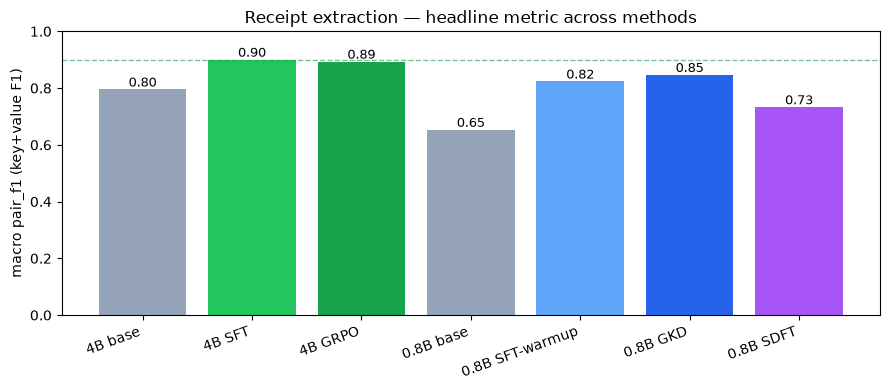

In [15]:
colors = ["#94a3b8","#22c55e","#16a34a","#94a3b8","#60a5fa","#2563eb","#a855f7"][:len(labels)]
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, vals, color=colors)
ax.set_ylabel("macro pair_f1 (key+value F1)"); ax.set_ylim(0, 1)
ax.set_title("Receipt extraction — headline metric across methods")
ax.axhline(0.900, ls="--", lw=1, color="#16a34a", alpha=.6)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.2f}", ha="center", fontsize=9)
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

### When to reach for which

| Method | Use it when… | Cost | Here |
|---|---|---|---|
| **SFT** | you have labeled targets — **always start here** | 1 model, teacher-forced | does ~all the work |
| **GRPO** | a reward has **headroom above SFT** (SFT leaves real errors) | G rollouts/step | flat (reward saturated) |
| **GKD** | you want a **smaller** model and have a **stronger teacher** | teacher + student in memory | real +0.024 gain |
| **SDFT** | you want to adapt **without a teacher** / **retain** prior skills | 1 model, gen + 2 forwards | label-free lift |

**Three findings worth remembering:**
1. **SFT is the workhorse**; RL only helps when the reward isn't already saturated.
2. **The teacher's distribution beats gold labels** when the student has headroom (distillation won where GRPO didn't).
3. **On-policy methods only fix what the model samples** — a cheap supervised warmup beats many on-policy steps from cold.

### (Optional) See it work — live extraction

Loads Qwen3.5-4B once and extracts a real receipt **with the SFT adapter enabled vs. disabled**
(same model, `disable_adapter()`), so you can watch SFT's effect directly. Needs ~9 GB VRAM and a
trained adapter at `outputs/sft/`. Set `RUN_LIVE = False` to skip.

In [16]:
RUN_LIVE = True
if RUN_LIVE and os.path.isdir("outputs/sft"):
    from peft import PeftModel
    from vlm_workshop.common import load_model, align_generation
    from vlm_workshop.data import build_messages
    from qwen_vl_utils import process_vision_info

    model = load_model(attn="sdpa", device_map={"": 0}).eval()
    align_generation(model, processor)
    model = PeftModel.from_pretrained(model, "outputs/sft")

    from vlm_workshop.metrics import extract_json, score

    ex = by["sroie"]
    msgs = build_messages("sroie", ex["image"], ex["target"], DEFAULT_MAX_PIXELS, with_answer=False)
    # enable_thinking=False -> direct JSON (matches how these adapters were trained & evaluated)
    text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True,
                                         enable_thinking=False)
    imgs, _ = process_vision_info(msgs)
    inp = processor(text=[text], images=imgs, return_tensors="pt").to(model.device)
    n_in = inp["input_ids"].shape[1]
    gold = json.loads(ex["target"])

    def extract():
        with torch.inference_mode():
            out = model.generate(**inp, max_new_tokens=384, do_sample=False,
                                  pad_token_id=processor.tokenizer.pad_token_id)
        raw = processor.tokenizer.decode(out[0][n_in:], skip_special_tokens=True)
        pred, ok = extract_json(raw)
        return pred, (score(pred, gold)["pair_f1"] if ok else 0.0), raw

    with model.disable_adapter():
        base_pred, base_f1, base_raw = extract()
    sft_pred, sft_f1, sft_raw = extract()
    print("=== GOLD ==="); print(json.dumps(gold, indent=2))
    print(f"\n=== BASE (adapter disabled) — pair_f1={base_f1:.2f} ===")
    print(json.dumps(base_pred, indent=2) if base_pred else textwrap.shorten(base_raw, 300))
    print(f"\n=== SFT (adapter enabled) — pair_f1={sft_f1:.2f} ===")
    print(json.dumps(sft_pred, indent=2) if sft_pred else textwrap.shorten(sft_raw, 300))
    del model; torch.cuda.empty_cache()
else:
    print("Skipped (RUN_LIVE=False or no outputs/sft adapter). Train one with train/sft.py first.")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

=== GOLD ===
{
  "company": "BOOK TA .K (TAMAN DAYA) SDN BHD",
  "date": "25/12/2018",
  "address": "NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.",
  "total": "9.00"
}

=== BASE (adapter disabled) — pair_f1=0.50 ===
{
  "company": "BOOK TA .K (TAMAN DAYA) SDN BHD",
  "date": "25/12/2018 8:13:39 PM",
  "address": "NO.55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.",
  "total": "9.00"
}

=== SFT (adapter enabled) — pair_f1=1.00 ===
{
  "company": "BOOK TA .K (TAMAN DAYA) SDN BHD",
  "date": "25/12/2018",
  "address": "NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.",
  "total": "9.00"
}


---
## Part 7 — Recap & exercises

**The four methods, one task:**

```
SFT   :  (image, prompt) ─────────────────► gold JSON            (imitate labels)
GRPO  :  sample G answers ─► reward each ──► push above-average   (RL from a scalar reward)
GKD   :  student samples ──► 4B teacher scores ─► match its dist  (learn a teacher's distribution)
SDFT  :  student samples ──► same model +gold-in-context scores   (teach yourself from a demo)
```

**Where it all lives:**
| Concept | File |
|---|---|
| unified data, SFT collator, GRPO dataset | `src/vlm_workshop/data.py` |
| leaf-multiset metrics (reward + eval) | `src/vlm_workshop/metrics.py` |
| local GRPO reward | `src/vlm_workshop/reward.py` |
| VLM GKD (teacher→student) | `src/vlm_workshop/distill.py`, `train/distill.py` |
| VLM SDFT (self-teacher) | `src/vlm_workshop/sdft.py`, `train/sdft.py` |
| SFT / GRPO entry points | `train/sft.py`, `train/grpo.py` |
| eval report | `scripts/eval.py` |

**Run the full pipeline:** `bash scripts/run_all.sh` (base-eval → SFT → SFT-eval → GRPO → GRPO-eval).
Full results & analysis: [`REPORT.md`](./REPORT.md).

**Exercises**
1. **Make GRPO win.** Under-train SFT (`python train/sft.py --limit-per-dataset 150 --epochs 1`), then
   run GRPO. Does the reward now have variance? Check `outputs/grpo/completions/`.
2. **Stricter reward.** Change `reward.WEIGHTS` to reward exact full-JSON match (all-or-nothing) and
   re-run GRPO — does the added headroom help?
3. **Sweep the divergence.** Distill with `--beta 0.0` vs `1.0` and compare (Part 4 says β barely moves it here — verify).
4. **SDFT vs SFT for retention.** Fine-tune the 0.8B on CORD only with SFT and with SDFT, then eval on
   SROIE. Which forgets less?